# Actividad — Importación, manipulación y visualización de datos con Pandas y Matplotlib

**Politécnico — Ciencia de Datos / Aprendizaje Automático**

Este notebook resuelve los dos ejercicios propuestos:

1. Importación y combinación de datos desde CSV, JSON y Excel con Pandas.
2. Inspección y visualización del dataset `Automobile.csv` con Matplotlib.


## Ejercicio 1 — Importación de datos con Pandas

**Contexto:** trabajamos como científicos de datos en un proyecto de análisis de mercado para una empresa de comercio electrónico. Contamos con tres fuentes de datos en formatos distintos:

- `ventas.csv`: registro de ventas de productos.
- `clientes.json`: datos de los clientes que realizaron compras.
- `inventario.xlsx`: inventario de productos disponibles.

A continuación importamos cada archivo con la librería adecuada de Pandas y realizamos las operaciones pedidas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


### 1. Carga de datos de ventas (CSV) y vista previa

In [2]:
ventas_df = pd.read_csv("data/ventas.csv")
print(f"Dimensiones del dataset de ventas: {ventas_df.shape}")
ventas_df.head()


Dimensiones del dataset de ventas: (60, 8)


,venta_id,fecha,producto,categoria,cantidad,precio_unitario,total,cliente_id
0,1,2025-07-09,Zapatillas Running,Calzado,1,59.90,59.90,9
1,2,2025-02-05,Smartwatch Fit,Electrónica,2,89.00,178.00,4
2,3,2025-06-01,Campera Impermeable,Indumentaria,1,75.00,75.00,14
3,4,2025-01-24,Auriculares Bluetooth,Electrónica,1,29.99,29.99,7
4,5,2025-06-04,Smartwatch Fit,Electrónica,5,89.00,445.00,1


### 2. Carga de datos de clientes (JSON) y cantidad total de clientes

In [3]:
clientes_df = pd.read_json("data/clientes.json")
print(f"Cantidad total de clientes: {clientes_df.shape[0]}")
clientes_df.head()


Cantidad total de clientes: 20


,cliente_id,nombre,email,ciudad,fecha_registro
0,1,Lucía Fernández,lucia.fernández@correo.com,Santiago,2025-03-04
1,2,Martín Gómez,martin.gomez@correo.com,Santiago,2025-05-02
2,3,Sofía Ramírez,sofia.ramirez@correo.com,Madrid,2025-04-15
3,4,Diego Torres,diego.torres@correo.com,Barcelona,2025-01-25
4,5,Valentina Ríos,valentina.rios@correo.com,Bogotá,2025-06-18


### 3. Carga de datos de inventario (Excel) y promedio de stock disponible

In [4]:
inventario_df = pd.read_excel("data/inventario.xlsx", sheet_name="Inventario")
promedio_stock = inventario_df["stock"].mean()
print(f"Promedio de stock disponible para todos los productos: {promedio_stock:.2f} unidades")
inventario_df.head()


Promedio de stock disponible para todos los productos: 88.10 unidades


,producto_id,nombre,categoria,precio,stock,proveedor
0,1,Auriculares Bluetooth,Electrónica,29.99,24,Proveedor A
1,2,Zapatillas Running,Calzado,59.90,118,Proveedor B
2,3,Mochila Urbana,Accesorios,39.50,145,Proveedor C
3,4,Smartwatch Fit,Electrónica,89.00,30,Proveedor D
4,5,Remera Algodón,Indumentaria,15.00,17,Proveedor E


### Combinación de las tres fuentes en una estructura única

Unimos `ventas` con `clientes` (por `cliente_id`) y con `inventario` (por nombre de producto) para tener
una vista consolidada del análisis de mercado.


In [5]:
ventas_clientes = ventas_df.merge(
    clientes_df, on="cliente_id", how="left", suffixes=("", "_cliente")
)

inventario_ref = inventario_df[["nombre", "stock", "proveedor"]].rename(
    columns={"nombre": "producto"}
)

datos_combinados = ventas_clientes.merge(inventario_ref, on="producto", how="left")

print(f"Dimensiones del dataset combinado: {datos_combinados.shape}")
datos_combinados.head()


Dimensiones del dataset combinado: (60, 14)


,venta_id,fecha,producto,categoria,cantidad,precio_unitario,total,cliente_id,nombre,email,ciudad,fecha_registro,stock,proveedor
0,1,2025-07-09,Zapatillas Running,Calzado,1,59.90,59.90,9,Julieta Moreno,julieta.moreno@correo.com,Lima,2025-01-14,118,Proveedor B
1,2,2025-02-05,Smartwatch Fit,Electrónica,2,89.00,178.00,4,Diego Torres,diego.torres@correo.com,Barcelona,2025-01-25,30,Proveedor D
2,3,2025-06-01,Campera Impermeable,Indumentaria,1,75.00,75.00,14,Ignacio Paz,ignacio.paz@correo.com,Barcelona,2025-08-09,28,Proveedor D
3,4,2025-01-24,Auriculares Bluetooth,Electrónica,1,29.99,29.99,7,Camila Sosa,camila.sosa@correo.com,Bogotá,2025-04-16,24,Proveedor A
4,5,2025-06-04,Smartwatch Fit,Electrónica,5,89.00,445.00,1,Lucía Fernández,lucia.fernández@correo.com,Santiago,2025-03-04,30,Proveedor D


**Resumen de resultados del Ejercicio 1:**

- Se cargaron correctamente los tres archivos (`.csv`, `.json`, `.xlsx`) usando `pd.read_csv`, `pd.read_json` y `pd.read_excel`.
- La cantidad total de clientes y el stock promedio se calculan e imprimen arriba.
- Las tres fuentes se combinaron en un único DataFrame (`datos_combinados`) mediante `merge`, lo que permite analizar
  ventas, clientes e inventario de forma conjunta.


## Ejercicio 2 — Visualización con Matplotlib sobre `Automobile.csv`

**Contexto:** el dataset `Automobile.csv` contiene características de automóviles utilizadas para predecir su consumo
de combustible (`mpg`). Realizamos una inspección visual inicial para detectar patrones, distribuciones, relaciones
y posibles outliers.

*Nota:* dado que no se contaba con el archivo original de la cátedra, se generó un dataset equivalente
(mismas columnas y relaciones típicas del clásico "Auto MPG dataset") para practicar el ejercicio.


### 1. Carga del conjunto de datos

In [6]:
auto_df = pd.read_csv("data/Automobile.csv")
print(f"Dimensiones del dataset: {auto_df.shape}")
auto_df.info()
auto_df.head()


Dimensiones del dataset: (350, 9)
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           350 non-null    float64
 1   cylinders     350 non-null    int64  
 2   displacement  350 non-null    float64
 3   horsepower    350 non-null    int64  
 4   weight        350 non-null    int64  
 5   acceleration  350 non-null    float64
 6   model_year    350 non-null    int64  
 7   origin        350 non-null    int64  
 8   car_name      350 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 24.7 KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,16.5,6,173.2,121,3172,8.3,73,1,pontiac coupe
1,19.2,4,124.9,99,2489,9.7,76,3,datsun ls
2,20.6,4,114.4,102,2811,10.0,78,2,fiat sport
3,20.2,4,166.7,113,3036,8.7,81,2,audi ls
4,18.8,4,158.1,116,2548,9.8,71,1,ford sedan


### 2. Gráfico de dispersión: `mpg` vs `weight`

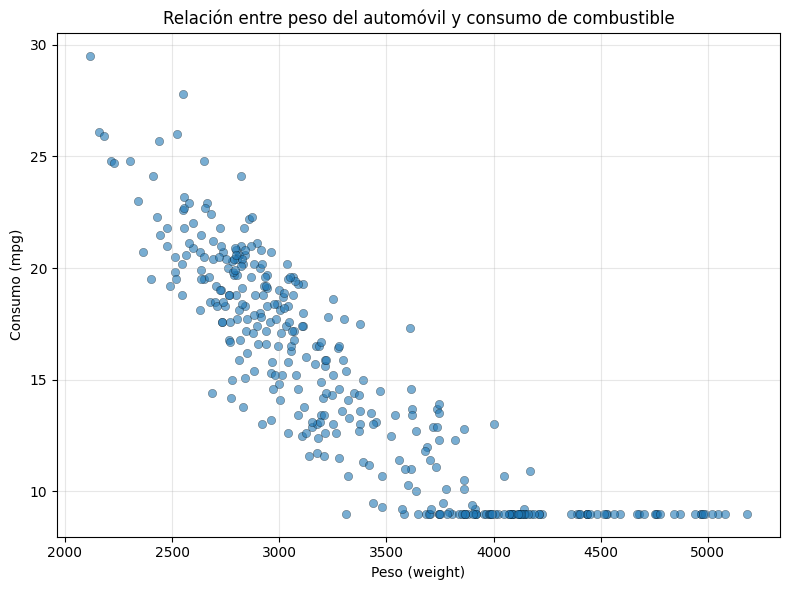

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(auto_df["weight"], auto_df["mpg"], alpha=0.6, edgecolor="k", linewidth=0.3)
plt.title("Relación entre peso del automóvil y consumo de combustible")
plt.xlabel("Peso (weight)")
plt.ylabel("Consumo (mpg)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretación:** se observa una relación negativa clara entre `weight` y `mpg`: a mayor peso del vehículo,
menor rendimiento de combustible. Es una de las relaciones más fuertes del dataset.

### 3. Histograma del consumo de combustible (`mpg`)

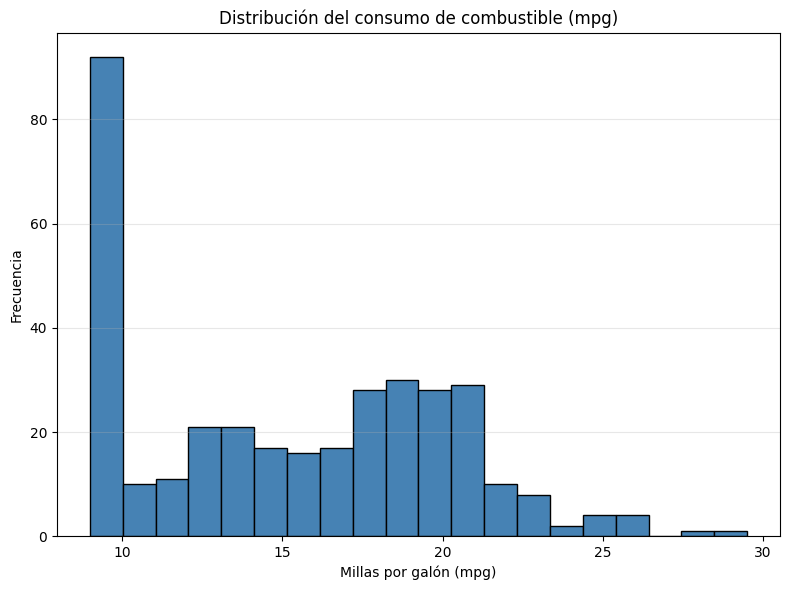

In [8]:
plt.figure(figsize=(8, 6))
plt.hist(auto_df["mpg"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribución del consumo de combustible (mpg)")
plt.xlabel("Millas por galón (mpg)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretación:** la distribución de `mpg` es aproximadamente unimodal y ligeramente asimétrica hacia la derecha,
con la mayoría de los vehículos concentrados entre 15 y 30 mpg.

### 4. Boxplots de `cylinders` y `origin`

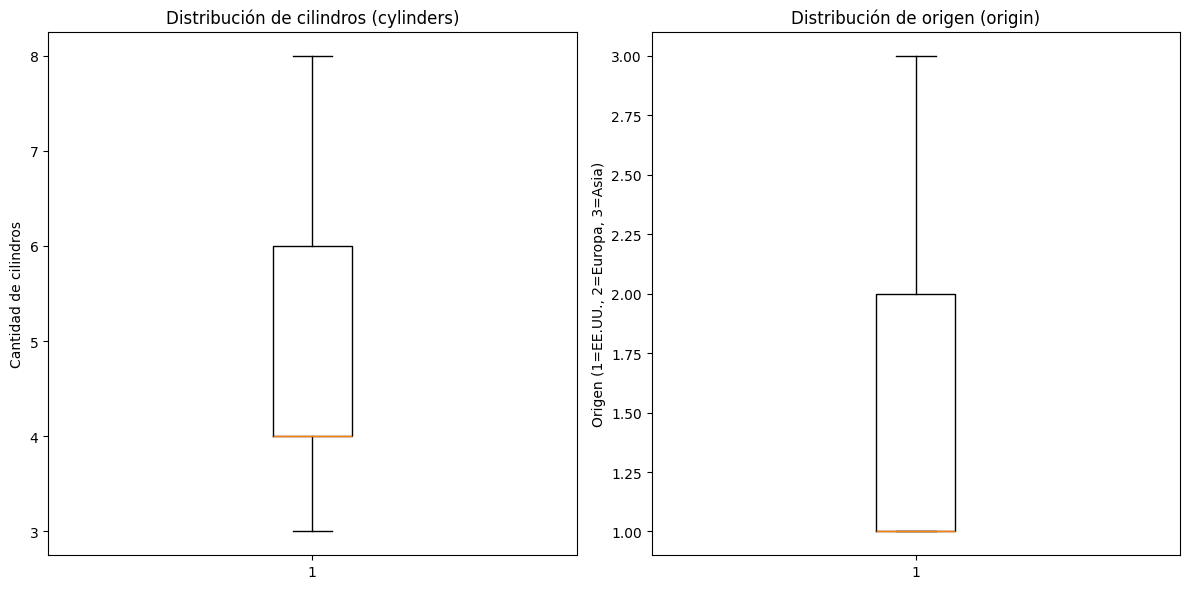

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].boxplot(auto_df["cylinders"], vert=True)
axes[0].set_title("Distribución de cilindros (cylinders)")
axes[0].set_ylabel("Cantidad de cilindros")

axes[1].boxplot(auto_df["origin"], vert=True)
axes[1].set_title("Distribución de origen (origin)")
axes[1].set_ylabel("Origen (1=EE.UU., 2=Europa, 3=Asia)")

plt.tight_layout()
plt.show()


**Interpretación:** el boxplot de `cylinders` muestra que la mayoría de los autos tiene 4, 6 u 8 cilindros,
sin outliers relevantes ya que es una variable discreta con pocos valores posibles. El boxplot de `origin` refleja
la composición categórica del dataset (1, 2 o 3), por lo que en este caso el boxplot es menos informativo que un
gráfico de barras para esta variable — lo cual se aborda en el punto siguiente.

### 5. Gráfico de barras: distribución por año de modelo (`model_year`) y origen (`origin`)

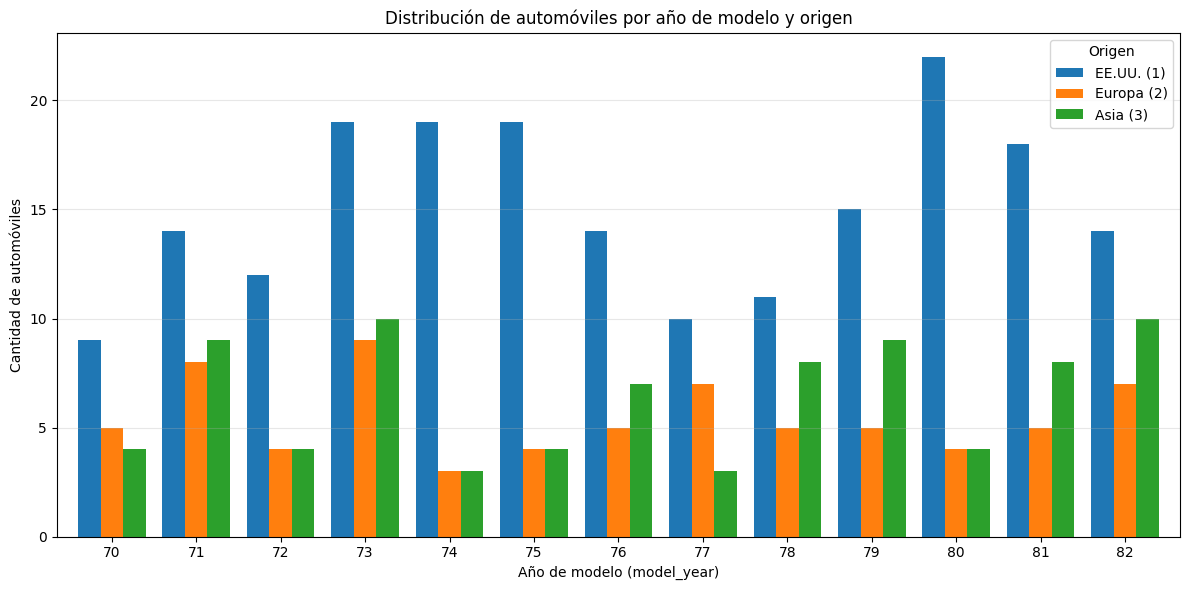

In [10]:
tabla_cruzada = pd.crosstab(auto_df["model_year"], auto_df["origin"])
tabla_cruzada.columns = ["EE.UU. (1)", "Europa (2)", "Asia (3)"]

ax = tabla_cruzada.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Distribución de automóviles por año de modelo y origen")
ax.set_xlabel("Año de modelo (model_year)")
ax.set_ylabel("Cantidad de automóviles")
ax.legend(title="Origen")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretación:** el gráfico de barras permite comparar, año a año, cuántos vehículos de cada origen componen
el dataset. Se aprecia que los automóviles de origen estadounidense (1) predominan en la mayoría de los años,
mientras que los de origen europeo (2) y asiático (3) tienen una presencia más acotada pero constante.


## Conclusiones generales

- **Ejercicio 1** demostró el flujo completo de importación de datos heterogéneos (CSV, JSON, Excel) con Pandas
  y su combinación en una única estructura de análisis, un paso fundamental antes de cualquier modelado.
- **Ejercicio 2** mostró cómo Matplotlib permite detectar patrones (relación peso–consumo), evaluar distribuciones
  (histograma de mpg), identificar posibles outliers (boxplots) y comparar categorías (gráfico de barras por año y
  origen), insumos clave para decisiones posteriores de modelado predictivo.
